## CONSTRUCCION DE RATIOS FINANCIEROS Y SCORE DE RIESGO CREDITICIO

En este notebook, se toma el panel consolidado y estandarizado, y se procede a la construcción de los ratios de estudio y puntajes de análisis, así como d elas visualizaciones de interés.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#2C4770", "#E8703A", "#3A9E8F", "#C94040", "#7B5EA7"]

df = pd.read_csv("../Data/processed/panel_limpio.csv")
df["periodo"] = df["periodo"].astype(str)
df = df.sort_values(["emisor", "periodo"]).reset_index(drop=True)

print(df.groupby("emisor")["periodo"].agg(["count", "min", "max"]))

        count     min     max
emisor                       
CELSIA     22  2021Q1  2026Q2
ENEL       21  2021Q2  2026Q2
EPM        22  2021Q1  2026Q2
ISA        22  2021Q1  2026Q2
ISAGEN     22  2021Q1  2026Q2


In [4]:
FLUJOS = ["ebitda", "gastos_financieros", "ingresos"]
STOCKS = ["deuda_cp", "deuda_lp", "caja"]

def calcular_ttm(df: pd.DataFrame) -> pd.DataFrame:
    """
    Para cada emisor-periodo, suma los últimos 4 trimestres de flujos
    y conserva el stock puntual del periodo.
    Requiere al menos 4 periodos por emisor.
    """
    frames = []
    for emisor, grupo in df.groupby("emisor"):
        grupo = grupo.sort_values("periodo").copy()
        for col in FLUJOS:
            grupo[f"{col}_ttm"] = grupo[col].rolling(4, min_periods=4).sum()
        for col in STOCKS:
            grupo[f"{col}_ttm"] = grupo[col]  # stocks: valor puntual
        grupo["ebitda_imputado_ttm"] = grupo["ebitda_imputado"].rolling(4).sum() > 0
        frames.append(grupo)
    return pd.concat(frames, ignore_index=True)

ttm = calcular_ttm(df)
# Conservar solo periodos con TTM completo (desde 2022Q1 en adelante)
ttm = ttm.dropna(subset=[f"{c}_ttm" for c in FLUJOS]).copy()

print(f"Periodos con TTM completo: {ttm.shape[0]}")
print(ttm.groupby("emisor")["periodo"].agg(["count", "min", "max"]))

Periodos con TTM completo: 94
        count     min     max
emisor                       
CELSIA     19  2021Q4  2026Q2
ENEL       18  2022Q1  2026Q2
EPM        19  2021Q4  2026Q2
ISA        19  2021Q4  2026Q2
ISAGEN     19  2021Q4  2026Q2


## Ventana TTM

La base contiene 109 observaciones: 22 períodos para CELSIA, EPM, ISA e ISAGEN, y 21 para ENEL porque comienza en 2021Q2. Al sumar cuatro trimestres consecutivos se obtienen 94 observaciones TTM, desde 2021Q4 para los emisores con información desde 2021Q1 y desde 2022Q1 para ENEL.

El cálculo TTM es apropiado para flujos como EBITDA, ingresos y gastos financieros, porque reduce la estacionalidad y permite comparar emisores con períodos trimestrales. Caja y deuda no se suman: se conserva el saldo puntual del último trimestre de cada ventana.

La comparación debe interpretarse con cautela porque el panel contiene EBITDA imputado en algunos períodos, especialmente de ENEL y EPM. Esa imputación puede afectar ratios, z-scores y el índice final.

In [5]:
ttm["deuda_neta"]          = ttm["deuda_cp_ttm"] + ttm["deuda_lp_ttm"] - ttm["caja_ttm"]
ttm["deuda_ebitda"]        = (ttm["deuda_cp_ttm"] + ttm["deuda_lp_ttm"]) / ttm["ebitda_ttm"]
ttm["cobertura_intereses"] = ttm["ebitda_ttm"] / ttm["gastos_financieros_ttm"]
ttm["liquidez_cp"]         = ttm["caja_ttm"] / ttm["deuda_cp_ttm"].replace(0, np.nan)
ttm["margen_ebitda"]       = ttm["ebitda_ttm"] / ttm["ingresos_ttm"]

RATIOS = ["deuda_ebitda", "cobertura_intereses", "liquidez_cp", "margen_ebitda"]

print("\n--- Ratios promedio por emisor (TTM) ---")
print(ttm.groupby("emisor")[RATIOS].mean().round(2))


--- Ratios promedio por emisor (TTM) ---
        deuda_ebitda  cobertura_intereses  liquidez_cp  margen_ebitda
emisor                                                               
CELSIA          4.35                 1.98         0.31           0.27
ENEL            1.33                 6.45         0.99           0.46
EPM             2.20                 3.04         1.12           0.24
ISA             4.27                 3.21         2.13           0.54
ISAGEN          4.82                 1.86         0.59           0.54


## Comentario: interpretación de los ratios

### Deuda/EBITDA

Mide cuántas veces el EBITDA TTM representa la deuda financiera. Un valor alto implica mayor apalancamiento y menor capacidad relativa de repago. El promedio más alto corresponde a ISAGEN (4,82x), seguido de CELSIA (4,35x) e ISA (4,27x). ENEL presenta el menor nivel promedio (1,33x), mientras EPM queda en una posición intermedia (2,20x).

### Cobertura de intereses

Mide cuántas veces el EBITDA cubre los gastos financieros. Un valor alto es favorable porque indica mayor margen para atender intereses. ENEL presenta la mejor cobertura promedio (6,45x). CELSIA (1,98x) e ISAGEN (1,86x) muestran mayor presión financiera, especialmente ISAGEN.

### Liquidez corriente

Se calcula como caja sobre deuda corriente. Un valor alto indica mayor respaldo inmediato para cubrir obligaciones de corto plazo. ISA destaca ampliamente (2,13x), seguida de EPM (1,12x) y ENEL (0,99x). CELSIA (0,31x) e ISAGEN (0,59x) presentan menor liquidez relativa.

### Margen EBITDA

Mide la proporción de los ingresos que se convierte en EBITDA. Un margen alto sugiere mayor eficiencia operativa, aunque no equivale por sí solo a menor riesgo crediticio. ISA e ISAGEN presentan el promedio más alto (0,54), seguidas de ENEL (0,46), CELSIA (0,27) y EPM (0,24).

### Lectura conjunta

No debe analizarse un ratio de forma aislada. ISAGEN combina alto apalancamiento, baja cobertura y baja liquidez. CELSIA también presenta presión por apalancamiento y liquidez. ENEL muestra el perfil relativo más favorable, mientras ISA compensa su deuda/EBITDA alta con liquidez y margen elevados.

In [6]:
## Celda 4 — Normalizar y construir índice compuesto
# Z-score dentro del panel completo
# deuda_ebitda: más alto = más riesgo → invertir signo
panel_ratios = ttm[["emisor", "periodo"] + RATIOS + ["ebitda_imputado_ttm"]].copy()

for ratio in RATIOS:
    mu = panel_ratios[ratio].mean()
    sigma = panel_ratios[ratio].std()
    z = (panel_ratios[ratio] - mu) / sigma
    # Ajustar signo: todos apuntan a "más alto = menos riesgo"
    panel_ratios[f"z_{ratio}"] = -z if ratio == "deuda_ebitda" else z

Z_COLS = [f"z_{r}" for r in RATIOS]

# Pesos: apalancamiento 60%, liquidez+margen 40%
PESOS = {
    "z_deuda_ebitda":        0.30,
    "z_cobertura_intereses": 0.30,
    "z_liquidez_cp":         0.20,
    "z_margen_ebitda":       0.20,
}
panel_ratios["indice"] = sum(
    panel_ratios[col] * peso for col, peso in PESOS.items()
)

print("\n--- Índice promedio por emisor ---")
print(panel_ratios.groupby("emisor")["indice"].mean().sort_values(ascending=False).round(3))


--- Índice promedio por emisor ---
emisor
ENEL      0.992
ISA       0.268
EPM       0.006
ISAGEN   -0.446
CELSIA   -0.768
Name: indice, dtype: float64


## Normalización e índice compuesto

Los ratios están en escalas diferentes, por lo que se transforman a z-scores usando todo el panel TTM. Cada z-score indica la posición relativa de una observación frente al conjunto de emisores y períodos.

El signo de `deuda_ebitda` se invierte porque un menor apalancamiento es favorable. En cobertura, liquidez y margen, un valor mayor se interpreta como favorable. Por tanto, un índice compuesto más alto representa mayor solidez relativa dentro de esta muestra.

Los pesos asignan 60% a apalancamiento y cobertura de intereses, y 40% a liquidez y margen. El índice no es una probabilidad de incumplimiento ni una calificación absoluta; es un ranking relativo dependiente de los emisores y períodos incluidos.

En promedio, ENEL obtiene el índice más alto (0,992), seguido de ISA (0,268) y EPM (0,006). ISAGEN (-0,446) y CELSIA (-0,768) presentan los resultados relativos más débiles, coherentes con sus mayores niveles de apalancamiento y menor cobertura/liquidez.

In [7]:
# Choque: caída de EBITDA de 20% (escenario Niño fuerte)
# Aplicado sobre el último periodo disponible de cada emisor
CAIDA_EBITDA = 0.20

ultimo = (
    ttm.sort_values("periodo")
    .groupby("emisor")
    .last()
    .reset_index()
)

stress = ultimo.copy()
stress["ebitda_ttm_stress"] = stress["ebitda_ttm"] * (1 - CAIDA_EBITDA)
stress["deuda_ebitda_stress"]        = (stress["deuda_cp_ttm"] + stress["deuda_lp_ttm"]) / stress["ebitda_ttm_stress"]
stress["cobertura_intereses_stress"] = stress["ebitda_ttm_stress"] / stress["gastos_financieros_ttm"]
stress["liquidez_cp_stress"]         = stress["liquidez_cp"]  # no cambia con EBITDA
stress["margen_ebitda_stress"]       = stress["ebitda_ttm_stress"] / stress["ingresos_ttm"]

RATIOS_STRESS = [r + "_stress" for r in RATIOS]

# Normalizar stress con los mismos parámetros del panel histórico
for ratio in RATIOS:
    mu = panel_ratios[ratio].mean()
    sigma = panel_ratios[ratio].std()
    z = (stress[f"{ratio}_stress"] - mu) / sigma
    stress[f"z_{ratio}_stress"] = -z if ratio == "deuda_ebitda" else z

# Forma más legible:
stress["indice_stress"] = (
    stress["z_deuda_ebitda_stress"]        * 0.30 +
    stress["z_cobertura_intereses_stress"] * 0.30 +
    stress["z_liquidez_cp_stress"]         * 0.20 +
    stress["z_margen_ebitda_stress"]       * 0.20
)

# Índice base del último periodo (para comparar manzanas con manzanas)
indice_base_ultimo = (
    panel_ratios.sort_values("periodo")
    .groupby("emisor")["indice"]
    .last()
    .reset_index()
    .rename(columns={"indice": "indice_base"})
)
stress = stress.merge(indice_base_ultimo, on="emisor")
stress["colchon"] = stress["indice_base"] - stress["indice_stress"]

print("\n--- Stress test: índice base vs estresado ---")
print(stress[["emisor", "indice_base", "indice_stress", "colchon"]]
      .sort_values("indice_stress", ascending=False)
      .round(3)
      .to_string(index=False))


--- Stress test: índice base vs estresado ---
emisor  indice_base  indice_stress  colchon
  ENEL        1.162          0.783    0.379
   EPM        0.262          0.006    0.255
   ISA        0.440          0.005    0.435
CELSIA       -0.641         -1.089    0.448
ISAGEN       -0.701         -1.147    0.446


In [8]:
## Choque 2: Aumento de tasas y deuda de corto plazo (escenario de liquidez)
AUMENTO_DEUDA_CP = 0.15

ultimo_liquidez = ultimo.copy()
ultimo_liquidez["deuda_cp_ttm_liquidez"] = ultimo_liquidez["deuda_cp_ttm"] * (1 + AUMENTO_DEUDA_CP)
ultimo_liquidez["deuda_ebitda_liquidez"] = (ultimo_liquidez["deuda_cp_ttm_liquidez"] + ultimo_liquidez["deuda_lp_ttm"]) / ultimo_liquidez["ebitda_ttm"]

stress_liquidez = ultimo_liquidez.copy()
stress_liquidez["cobertura_intereses_liquidez"] = stress_liquidez["ebitda_ttm"] / stress_liquidez["gastos_financieros_ttm"]
stress_liquidez["liquidez_cp_liquidez"] = stress_liquidez["caja_ttm"] / stress_liquidez["deuda_cp_ttm_liquidez"].replace(0, np.nan)
stress_liquidez["margen_ebitda_liquidez"] = stress_liquidez["ebitda_ttm"] / stress_liquidez["ingresos_ttm"]
stress_liquidez["deuda_ebitda_liquidez"] = (stress_liquidez["deuda_cp_ttm_liquidez"] + stress_liquidez["deuda_lp_ttm"]) / stress_liquidez["ebitda_ttm"]

RATIOS_LIQUIDEZ = [r + "_liquidez" for r in RATIOS]

for ratio in RATIOS:
    mu = panel_ratios[ratio].mean()
    sigma = panel_ratios[ratio].std()
    z = (stress_liquidez[f"{ratio}_liquidez"] - mu) / sigma
    stress_liquidez[f"z_{ratio}_liquidez"] = -z if ratio == "deuda_ebitda" else z

stress_liquidez["indice_liquidez"] = (
    stress_liquidez["z_deuda_ebitda_liquidez"]        * 0.30 +
    stress_liquidez["z_cobertura_intereses_liquidez"] * 0.30 +
    stress_liquidez["z_liquidez_cp_liquidez"]         * 0.20 +
    stress_liquidez["z_margen_ebitda_liquidez"]       * 0.20
)

stress_liquidez = stress_liquidez.merge(indice_base_ultimo, on="emisor")
stress_liquidez["colchon_liquidez"] = stress_liquidez["indice_base"] - stress_liquidez["indice_liquidez"]

print("\n--- Stress test de liquidez: índice base vs estresado ---")
print(stress_liquidez[["emisor", "indice_base", "indice_liquidez", "colchon_liquidez"]]
      .sort_values("indice_liquidez", ascending=False)
      .round(3)
      .to_string(index=False))


--- Stress test de liquidez: índice base vs estresado ---
emisor  indice_base  indice_liquidez  colchon_liquidez
  ENEL        1.162            1.097             0.065
   ISA        0.440            0.316             0.125
   EPM        0.262            0.204             0.057
CELSIA       -0.641           -0.681             0.040
ISAGEN       -0.701           -0.722             0.021


## Stress test con caída de EBITDA

El escenario reduce el EBITDA TTM de cada emisor en 20% y mantiene constantes la deuda, la caja, los gastos financieros y los ingresos. Por eso empeoran simultáneamente deuda/EBITDA, cobertura de intereses y margen EBITDA; liquidez corriente permanece sin cambios.

En el último período disponible, el índice estresado queda así:

- ENEL: 0.783, con una pérdida de 0,379 puntos.
- EPM: 0.006, con una pérdida de 0,255 puntos.
- ISA: 0.005, con una pérdida de 0,435 puntos.
- CELSIA: -1.089, con una pérdida de 0,448 puntos.
- ISAGEN: -1.147, con una pérdida de 0,446 puntos.

CELSIA e ISAGEN presentan los mayores colchones perdidos, aproximadamente 0,45 puntos, porque parten de una combinación más frágil de apalancamiento, cobertura y liquidez. ENEL conserva el índice más alto después del choque, aunque también pierde capacidad relativa.

## Stress test con alza de deuda

El escenario contempla un alza en los cotos de deuda de corto plazo, alzando los costos un 15% y manteniendo constante las demás variables. 

En el último periodo, el índice queda de la forma:

 - ENEL: 1.097, con una caída de 0,065 puntos.
 - ISA: 0.316, con una caída de 0.125 puntos. 
 - EPM: 0.204, con una caída de 0.057 puntos.
 - CELSIA: -0.681, con una caída de 0.04 puntos.
 - ISAGEN: -0.722, con una caída de 0.021 puntos.

En este caso, ISA en la emprea con el mayor colchón perdido, debido a su mayor índice de apalancamiento, pero que compensa con un mejor desempeño en otras áreas, permitiéndole mantener un nivel aún sólido.

El colchón se define como `índice base - índice estresado`. No representa capital regulatorio ni una pérdida monetaria; mide cuánto se deteriora este índice relativo bajo el escenario planteado.

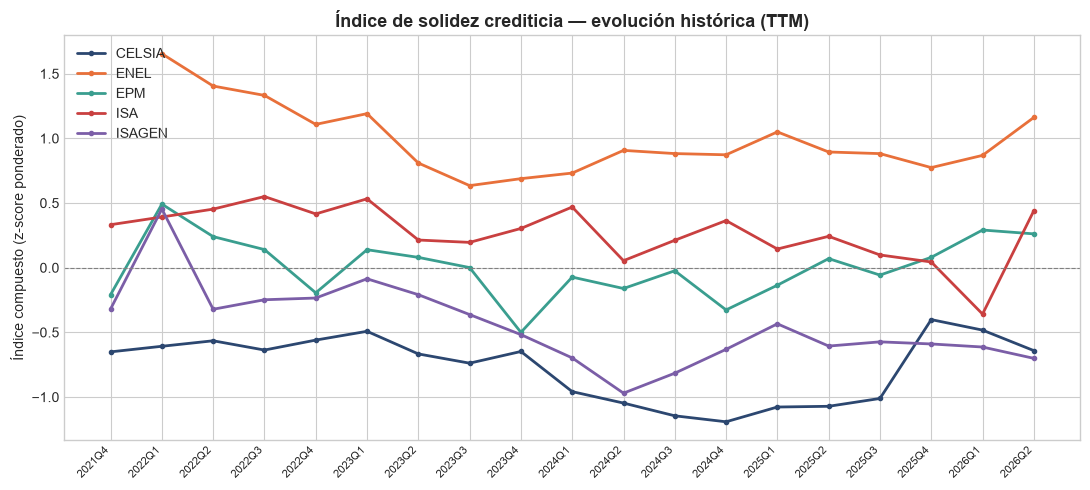

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
for i, (emisor, grupo) in enumerate(panel_ratios.groupby("emisor")):
    ax.plot(grupo["periodo"], grupo["indice"],
            label=emisor, color=COLORS[i], linewidth=2, marker="o", markersize=3)

# Rotar labels del eje X para legibilidad
ax.set_xticks(range(len(panel_ratios["periodo"].unique())))
ax.set_xticklabels(sorted(panel_ratios["periodo"].unique()), rotation=45, ha="right", fontsize=8)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("Índice de solidez crediticia — evolución histórica (TTM)", fontsize=13, fontweight="bold")
ax.set_ylabel("Índice compuesto (z-score ponderado)")
ax.legend(loc="upper left", framealpha=0.9)
plt.tight_layout()
plt.savefig("../outputs/grafico1_evolucion_historica.png", dpi=150)
plt.show()

## Evolución histórica

La primera gráfica permite observar la trayectoria temporal del índice TTM. Conviene buscar tendencias persistentes, cambios bruscos y convergencias entre emisores, en lugar de interpretar un solo trimestre.

Un deterioro sostenido del índice puede reflejar aumento del apalancamiento, caída de cobertura o reducción de liquidez/margen. Las diferencias entre líneas también deben leerse junto con los datos imputados, ya que una imputación puede suavizar o alterar la evolución observada.

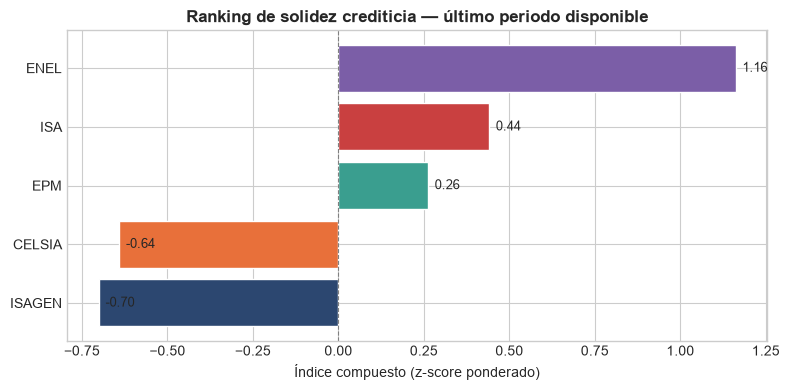

In [10]:
ultimo_rank = panel_ratios.sort_values("periodo").groupby("emisor").last().reset_index()
ultimo_rank = ultimo_rank.sort_values("indice")

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(ultimo_rank["emisor"], ultimo_rank["indice"],
               color=[COLORS[i] for i in range(len(ultimo_rank))], edgecolor="white")
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("Ranking de solidez crediticia — último periodo disponible", fontsize=12, fontweight="bold")
ax.set_xlabel("Índice compuesto (z-score ponderado)")
for bar, val in zip(bars, ultimo_rank["indice"]):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/grafico2_ranking.png", dpi=150)
plt.show()

## Ranking del último período

El ranking resume la solidez relativa en el último período disponible de cada emisor. Un valor positivo indica una posición superior al promedio del panel histórico; un valor negativo indica una posición inferior.

Según los resultados, ENEL ocupa el primer lugar, seguido de ISA y EPM. CELSIA e ISAGEN ocupan las posiciones inferiores. Este orden no debe interpretarse como una calificación crediticia definitiva, porque depende de la muestra, los pesos elegidos y la calidad de los datos imputados.

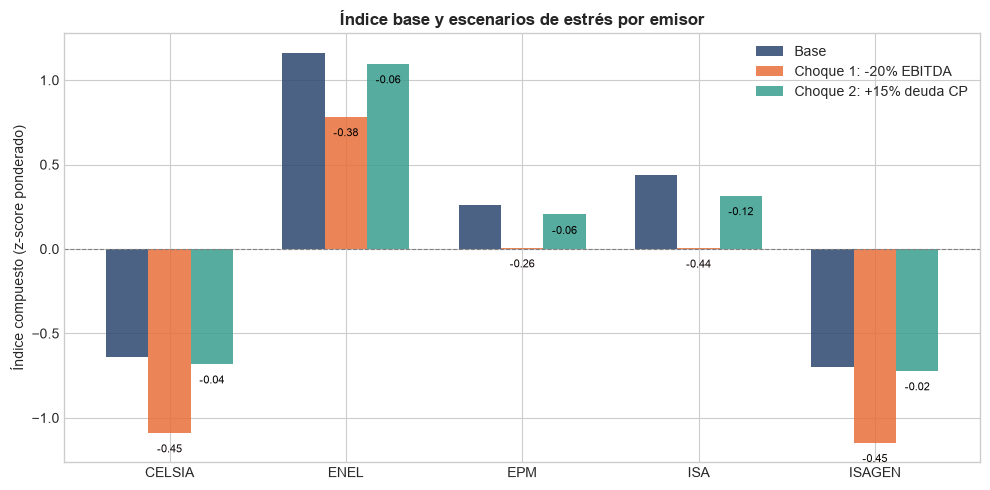

In [17]:
x = np.arange(len(stress))
width = 0.24

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(
    x - width,
    stress["indice_base"],
    width,
    label="Base",
    color="#2C4770",
    alpha=0.85,
)
bars2 = ax.bar(
    x,
    stress["indice_stress"],
    width,
    label="Choque 1: -20% EBITDA",
    color="#E8703A",
    alpha=0.85,
)
bars3 = ax.bar(
    x + width,
    stress_liquidez["indice_liquidez"],
    width,
    label="Choque 2: +15% deuda CP",
    color="#3A9E8F",
    alpha=0.85,
)

ax.set_xticks(x)
ax.set_xticklabels(stress["emisor"].tolist(), fontsize=10)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("Índice base y escenarios de estrés por emisor", fontsize=12, fontweight="bold")
ax.set_ylabel("Índice compuesto (z-score ponderado)")
ax.legend()

# Anotar el deterioro de cada escenario frente al índice base.
for position, (_, base_row) in enumerate(stress.iterrows()):
    liquidity_row = stress_liquidez.iloc[position]
    ax.annotate(
        f"-{base_row['colchon']:.2f}",
        xy=(x[position], base_row["indice_stress"]),
        xytext=(0, -14),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        color="#0A0402",
    )
    ax.annotate(
        f"-{liquidity_row['colchon_liquidez']:.2f}",
        xy=(x[position] + width, liquidity_row["indice_liquidez"]),
        xytext=(0, -14),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        color="#000000",
    )

plt.tight_layout()
plt.savefig("../outputs/grafico3_stress.png", dpi=150)
plt.show()

## Comparación base versus estrés

Esta gráfica compara la posición de cada emisor antes y después de una caída de 20% en EBITDA. La distancia entre las barras representa el deterioro del índice compuesto bajo el escenario adverso.

El resultado muestra que CELSIA e ISAGEN terminan con los índices estresados más bajos. ENEL permanece con el índice estresado más alto, mientras ISA y EPM convergen cerca de cero. El choque afecta más a los emisores con menor cobertura y mayor deuda/EBITDA, porque la caída del EBITDA deteriora dos ratios centrales del índice.

In [19]:
resumen = stress[[
    "emisor",
    "indice_base",
    "indice_stress",
    "colchon",
    "deuda_ebitda",
    "cobertura_intereses",
    "liquidez_cp",
    "margen_ebitda",
]].copy()

resumen = resumen.merge(
    stress_liquidez[["emisor", "indice_liquidez", "colchon_liquidez"]],
    on="emisor",
    how="left",
)

resumen.columns = [
    "Emisor",
    "Índice base",
    "Índice estresado EBITDA",
    "Colchón choque EBITDA",
    "Deuda/EBITDA",
    "Cobertura intereses",
    "Liquidez CP",
    "Margen EBITDA",
    "Índice estresado deuda CP",
    "Colchón choque deuda CP",
]

resumen = resumen.sort_values("Índice base", ascending=False).round(3)
resumen.to_csv("../outputs/tabla_resumen.csv", index=False)
print(resumen.to_string(index=False))

Emisor  Índice base  Índice estresado EBITDA  Colchón choque EBITDA  Deuda/EBITDA  Cobertura intereses  Liquidez CP  Margen EBITDA  Índice estresado deuda CP  Colchón choque deuda CP
  ENEL        1.162                    0.783                  0.379         1.225                5.963        1.842          0.472                      1.097                    0.065
   ISA        0.440                    0.005                  0.435         4.429                2.830        3.668          0.450                      0.316                    0.125
   EPM        0.262                    0.006                  0.255         1.633                2.981        1.463          0.288                      0.204                    0.057
CELSIA       -0.641                   -1.089                  0.448         5.072                1.576        0.294          0.526                     -0.681                    0.040
ISAGEN       -0.701                   -1.147                  0.446         5.150    

## Tabla final y lectura crediticia

La tabla final reúne el índice base, el índice bajo estrés, el colchón perdido y los cuatro ratios del último período. Los resultados principales son:

| Emisor | Índice base | Índice estresado caída EBITDA | Colchón perdido | Deuda/EBITDA | Cobertura | Liquidez CP | Margen EBITDA | Índice estresado deuda CP | Colchón deuda CP
|---|---:|---:|---:|---:|---:|---:|---:| ---: | ---:
| ENEL | 1,162 | 0,783 | 0,379 | 1,225x | 5,963x | 1,842x | 47,2% | 1,097 | 0,065
| ISA | 0,440 | 0,005 | 0,435 | 4,429x | 2,830x | 3,668x | 45,0% | 0,316 | 0,125
| EPM | 0,262 | 0,006 | 0,255 | 1,633x | 2,981x | 1,463x | 28,8% | 0,204 | 0,057
| CELSIA | -0,641 | -1,089 | 0,448 | 5,072x | 1,576x | 0,294x | 52,6% |-0,681 | 0,04
| ISAGEN | -0,701 | -1,147 | 0,446 | 5,150x | 1,338x | 0,245x | 53,1% | -0,722 | 0,021

La lectura conjunta sugiere tres perfiles: ENEL presenta la mejor combinación de apalancamiento, cobertura y liquidez; ISA tiene un apalancamiento elevado, pero está respaldada por liquidez y margen; EPM se mantiene en una posición intermedia; CELSIA e ISAGEN muestran mayor vulnerabilidad financiera relativa.

Estos resultados son evidencia exploratoria, no una probabilidad de incumplimiento. Antes de presentar el índice como herramienta final conviene hacer análisis de sensibilidad a los pesos, separar observaciones imputadas y probar escenarios adicionales sobre gastos financieros y caja.

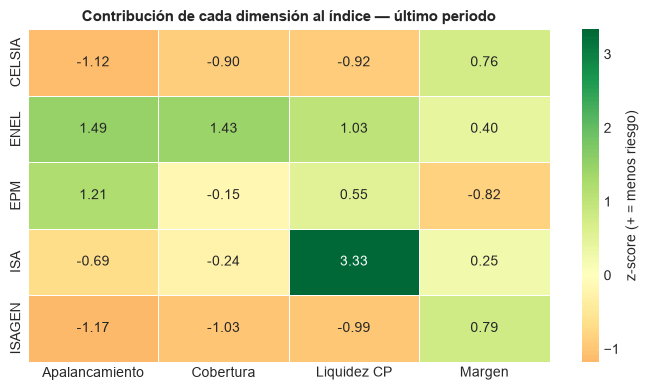

In [20]:
# Celda nueva — heatmap de z-scores del último periodo
Z_COLS = ["z_deuda_ebitda", "z_cobertura_intereses", "z_liquidez_cp", "z_margen_ebitda"]
ultimo_z = (
    panel_ratios.sort_values("periodo")
    .groupby("emisor")[Z_COLS]
    .last()
)
ultimo_z.index.name = None
ultimo_z.columns = ["Apalancamiento", "Cobertura", "Liquidez CP", "Margen"]

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    ultimo_z,
    annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, linewidths=0.5, ax=ax,
    cbar_kws={"label": "z-score (+ = menos riesgo)"}
)
ax.set_title("Contribución de cada dimensión al índice — último periodo", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/grafico4_heatmap.png", dpi=150)
plt.show()